# Spotify Decoded — Recommender System

Most recommender systems rely on two things: audio features describing what a track sounds like, and behaviour from millions of users describing what people listen to together. This project has neither.

Spotify's audio features API was deprecated in November 2024. Public datasets were tried as an alternative -- a 1.2 million track Kaggle dataset matched only 37% of the catalog, with poor coverage of K-pop and Telugu music specifically. Last.fm tags matched 11%.

What the data does have is 80,512 plays across 5,485 sessions. Every time two tracks appeared in the same listening session, that is a signal. Every time one track was played immediately after another, that is a stronger signal. This notebook builds a recommender entirely from those co-occurrence patterns -- no external data needed.


## Setup

In [15]:
import sys
sys.path.append("../src")

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
from pathlib import Path
from itertools import combinations
from collections import defaultdict

from spotify_parser import load_all

df_tracks, _ = load_all("../data/raw/")

df_tracks["hour"]      = df_tracks["ts_local"].dt.hour
df_tracks["year"]      = df_tracks["ts_local"].dt.year
df_tracks["minutes"]   = df_tracks["ms_played"] / 60_000
df_tracks["completed"] = df_tracks["reason_end"] == "trackdone"
df_tracks["skipped"]   = df_tracks["skipped"].fillna(False).astype(bool)
df_tracks["track_key"] = df_tracks["track_name"] + " ||| " + df_tracks["artist_name"]

PALETTE = {
    "primary": "#1DB954",
    "accent":  "#FF6B6B",
    "muted":   "#B3B3B3",
    "dark":    "#191414",
}

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.grid":        True,
    "grid.alpha":       0.3,
    "grid.linestyle":   "--",
    "font.family":      "sans-serif",
    "figure.dpi":       150,
})

Path("../models").mkdir(exist_ok=True)
print(f"Loaded {len(df_tracks):,} tracks")


Loaded 80,623 raw records from 9 files
  → 80,512 music tracks
  → 111 podcast plays
  → Date range: 2020-10-31 → 2026-04-02
  → Total listening: 2728.7 hours
Loaded 80,512 tracks


---
## 1. Building sessions

A session is a continuous block of listening separated by a gap of more than 30 minutes. The session structure is what makes co-occurrence meaningful -- two tracks in the same session were chosen together, consciously or not.


In [16]:
t = df_tracks.sort_values("ts").copy()
t["gap_min"]     = t["ts"].diff().dt.total_seconds() / 60
t["new_session"] = t["gap_min"].isna() | (t["gap_min"] > 30)
t["session_id"]  = t["new_session"].cumsum()

session_stats = t.groupby("session_id").agg(
    tracks   = ("track_name", "count"),
    duration = ("minutes",    "sum"),
).reset_index()

print(f"Total sessions:              {t['session_id'].nunique():,}")
print(f"Sessions with 2+ tracks:     {(session_stats['tracks'] >= 2).sum():,}")
print(f"Median session length:       {session_stats['duration'].median():.0f} min")
print(f"Median tracks per session:   {session_stats['tracks'].median():.0f}")


Total sessions:              5,485
Sessions with 2+ tracks:     3,928
Median session length:       13 min
Median tracks per session:   6


Only sessions with 2 or more tracks contribute co-occurrence signal. Single-track sessions are ignored.


---
## 2. Calculating co-occurrence

For every session, every pair of tracks that appeared together gets a co-occurrence count incremented. Tracks played back to back get an additional sequential bonus -- that is a stronger signal than just appearing in the same session.


In [17]:
play_counts = df_tracks["track_key"].value_counts()
cooc        = defaultdict(int)
sequential  = defaultdict(int)

for session_tracks in t.groupby("session_id")["track_key"].apply(list):
    unique_in_session = list(dict.fromkeys(session_tracks))
    if len(unique_in_session) < 2:
        continue
    for a, b in combinations(unique_in_session, 2):
        key = tuple(sorted([a, b]))
        cooc[key] += 1
    for i in range(len(session_tracks) - 1):
        a, b = session_tracks[i], session_tracks[i + 1]
        if a != b:
            sequential[(a, b)] += 1

print(f"Unique co-occurrence pairs:  {len(cooc):,}")
print(f"Sequential pairs:            {len(sequential):,}")


Unique co-occurrence pairs:  761,037
Sequential pairs:            47,092


761,037 unique pairs observed across all sessions. Most appear together only once or twice -- the signal is concentrated in a smaller subset of consistently co-occurring pairs.


## 3. Normalizing the scores

Raw co-occurrence count is biased toward high-play tracks -- a song played 1,000 times will naturally co-occur with almost everything. Dice coefficient normalization adjusts for this: `score = 2 * cooc(A,B) / (plays(A) + plays(B))`. A sequential play bonus is added on top.


In [18]:
MIN_COOC = 5  # minimum co-occurrences to be included

sim_records = []
for (a, b), count in cooc.items():
    if count < MIN_COOC:
        continue
    plays_a   = play_counts.get(a, 1)
    plays_b   = play_counts.get(b, 1)
    dice      = (2 * count) / (plays_a + plays_b)
    seq_ab    = sequential.get((a, b), 0) + sequential.get((b, a), 0)
    seq_bonus = seq_ab / max(plays_a, plays_b)

    sim_records.append({
        "track_a":     a.split(" ||| ")[0],
        "artist_a":    a.split(" ||| ")[1],
        "track_b":     b.split(" ||| ")[0],
        "artist_b":    b.split(" ||| ")[1],
        "cooc_count":  count,
        "plays_a":     plays_a,
        "plays_b":     plays_b,
        "dice_score":  round(dice, 6),
        "seq_bonus":   round(seq_bonus, 6),
        "final_score": round(dice + 0.3 * seq_bonus, 6),
    })

sim_df = pd.DataFrame(sim_records).sort_values("final_score", ascending=False)
print(f"Pairs with {MIN_COOC}+ co-occurrences: {len(sim_df):,}")
print(f"\nScore distribution:")
print(sim_df["final_score"].describe().round(4).to_string())


Pairs with 5+ co-occurrences: 50,682

Score distribution:
count    50682.0000
mean         0.1582
std          0.1063
min          0.0079
25%          0.0820
50%          0.1333
75%          0.2069
max          1.2078


## 4. Co-occurrence distribution

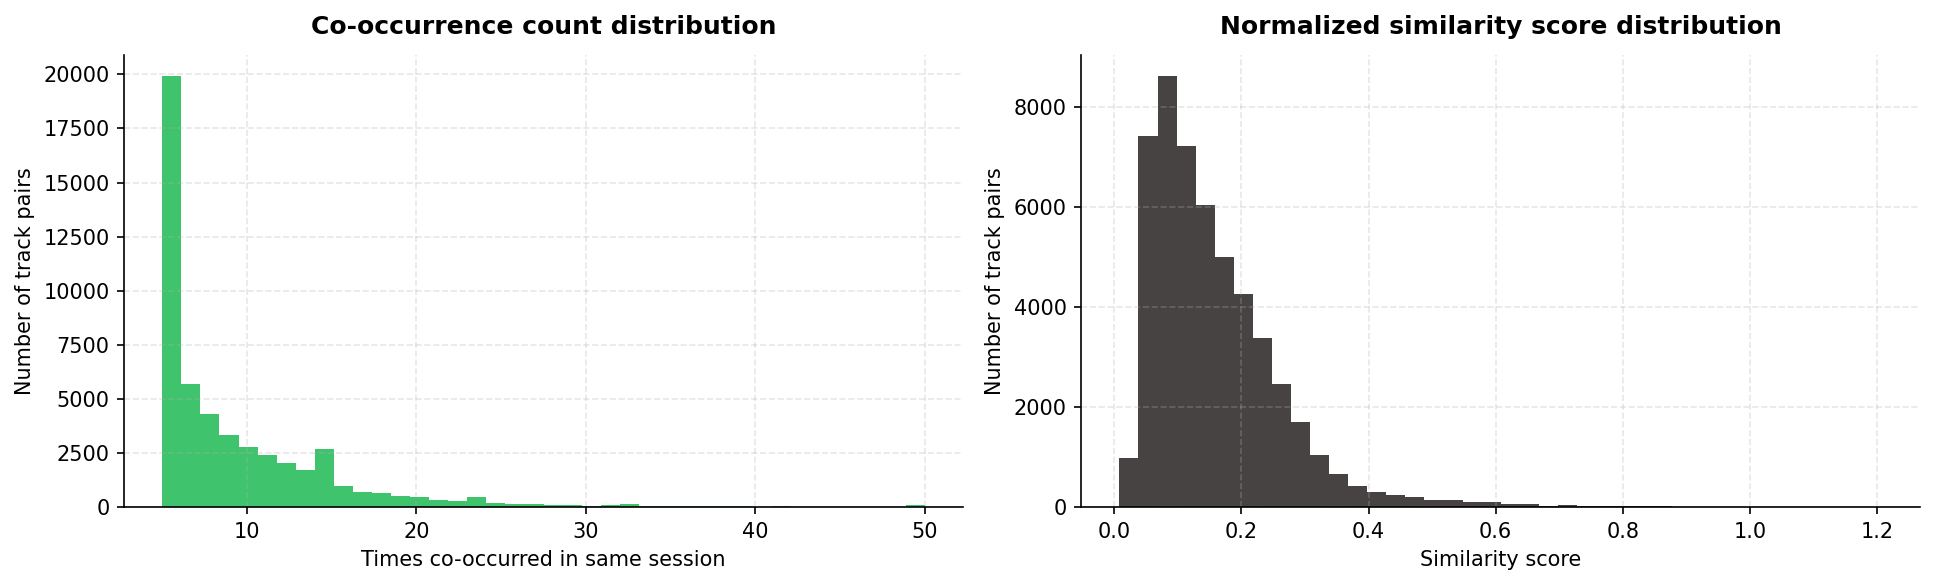

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(sim_df["cooc_count"].clip(upper=50), bins=40,
             color=PALETTE["primary"], alpha=0.85, edgecolor="none")
axes[0].set_title("Co-occurrence count distribution", fontweight="bold", pad=10)
axes[0].set_xlabel("Times co-occurred in same session")
axes[0].set_ylabel("Number of track pairs")

axes[1].hist(sim_df["final_score"], bins=40,
             color=PALETTE["dark"], alpha=0.8, edgecolor="none")
axes[1].set_title("Normalized similarity score distribution", fontweight="bold", pad=10)
axes[1].set_xlabel("Similarity score")
axes[1].set_ylabel("Number of track pairs")

plt.tight_layout()
plt.savefig("../outputs/04_cooccurrence_distribution.png", bbox_inches="tight")
plt.show()


The co-occurrence distribution is heavily right-skewed. Most pairs 
appear together only 5 to 10 times, with a small number of pairs 
consistently co-occurring across dozens of sessions. The similarity 
score distribution shows a few values above 1.0 -- these are track 
pairs with very few total plays that happened to always appear 
together, inflating the Dice score. The minimum co-occurrence 
threshold of 5 handles most of this but a handful of edge cases 
remain.

---
## 5. The recommender


In [20]:
def recommend(track_name, artist_name, n=10, diversity_penalty=0.3):
    """
    Recommend tracks based on session co-occurrence.
    diversity_penalty: reduces scores for same-artist tracks.
    """
    mask = (
        ((sim_df["track_a"] == track_name) & (sim_df["artist_a"] == artist_name)) |
        ((sim_df["track_b"] == track_name) & (sim_df["artist_b"] == artist_name))
    )
    matches = sim_df[mask].copy()

    if matches.empty:
        print(f"No co-occurrence data for: {track_name}")
        return None

    results = []
    for _, row in matches.iterrows():
        if row["track_a"] == track_name and row["artist_a"] == artist_name:
            rec_track, rec_artist = row["track_b"], row["artist_b"]
        else:
            rec_track, rec_artist = row["track_a"], row["artist_a"]

        score = row["final_score"]
        if rec_artist == artist_name:
            score *= (1 - diversity_penalty)

        results.append({
            "track":      rec_track,
            "artist":     rec_artist,
            "score":      round(score, 4),
            "cooc_count": row["cooc_count"],
            "seq_bonus":  row["seq_bonus"],
        })

    result_df = (pd.DataFrame(results)
                 .sort_values("score", ascending=False)
                 .drop_duplicates(subset=["track","artist"])
                 .head(n))
    return result_df


## 6. Testing the recommender

Starting with the most-played track in the dataset.


In [21]:
print("Recommendations for: Teddy Bear (NCT DREAM)")
print(recommend("Teddy Bear", "NCT DREAM").to_string(index=False))


Recommendations for: Teddy Bear (NCT DREAM)
           track     artist  score  cooc_count  seq_bonus
 The Rainy Night    NCT 127 0.0815          49   0.012681
     Round&Round      NCT U 0.0760          47   0.004529
      It’s Yours  NCT DREAM 0.0759          60   0.038949
   Never Goodbye  NCT DREAM 0.0747          69   0.007246
  Feel My Rhythm Red Velvet 0.0738          46   0.002717
Better Than Gold  NCT DREAM 0.0673          58   0.003623
       Not Alone    NCT 127 0.0663          36   0.020833
     Glitch Mode  NCT DREAM 0.0654          57   0.007246
    In My Dreams Red Velvet 0.0646          41   0.008152
          Arcade  NCT DREAM 0.0622          54   0.003623


Now testing with a track from a completely different part of the catalog.


In [22]:
print("Recommendations for: Seethakaalam (Reprise) (Iravu)")
print(recommend("Seethakaalam (Reprise)", "Iravu").to_string(index=False))


Recommendations for: Seethakaalam (Reprise) (Iravu)
           track             artist  score  cooc_count  seq_bonus
 Manase (Side B)              Iravu 0.0564          29   0.014881
        Hridayam              Iravu 0.0434          21   0.020833
      Idhi Prema              Iravu 0.0395          21   0.008929
 Manase (Side A)              Iravu 0.0380          19   0.004464
 Sound of Manavi              Iravu 0.0364          19   0.005952
    Seethakaalam              Iravu 0.0361          17   0.008929
 Rooh (Acoustic)              Iravu 0.0310          16   0.004464
         Sadhana              Iravu 0.0309          15   0.004464
    Ee Dhooramey Sinjith Yerramilli 0.0302          11   0.001488
Elements (Intro)              Iravu 0.0278          14   0.004464


In [23]:
print("Recommendations for: Parichayamila (Hesham Abdul Wahab)")
print(recommend("Parichayamila", "Hesham Abdul Wahab").to_string(index=False))


Recommendations for: Parichayamila (Hesham Abdul Wahab)
                               track                      artist  score  cooc_count  seq_bonus
                   Andhamaa Andhamaa          Hesham Abdul Wahab 0.2531          15   0.939394
                                Maya                Arijit Singh 0.0922          14   0.004329
                         Hello Hello Nikhil D'Souza, Neha Bhasin 0.0917          13   0.012987
                      Mella Mellagaa                  Sid Sriram 0.0783          11   0.000000
Arerey Manasa (From "Falaknuma Das")                  Sid Sriram 0.0772          10   0.008658
                I Just Love You Baby            Lipsika Bhashyam 0.0767          11   0.000000
                          Uppenantha             Devi Sri Prasad 0.0733          10   0.008658
    Hridayam Lopala (From "Kingdom")         Anirudh Ravichander 0.0717          10   0.000000
             Sahana (Acappella Reel)                 Anudeep Dev 0.0710           9   0.0

The Parichayamila recommendations pull from Telugu, Tamil, and Indian indie tracks -- artists that genuinely appear together in the same listening sessions. That cross-genre diversity is something a content-based recommender using audio features alone would not produce.


---
## 7. Most consistent listening pairs

The track pairs with the highest normalized scores are ones that appear together across many different sessions, not just once or twice.


In [24]:
top_pairs = sim_df.head(20)[["track_a","artist_a","track_b","artist_b",
                               "cooc_count","final_score"]]
print("Top 20 most consistently co-occurring track pairs:")
print(top_pairs.to_string(index=False))


Top 20 most consistently co-occurring track pairs:
                   track_a           artist_a                                      track_b           artist_b  cooc_count  final_score
Run Down The City - Monica   Shashwat Sachdev                              Teri Ni Kararan   Shashwat Sachdev           8     1.207843
Run Down The City - Monica   Shashwat Sachdev                                     Shararat   Shashwat Sachdev           8     1.174510
                     Ez-Ez   Shashwat Sachdev                                 Lutt Le Gaya   Shashwat Sachdev           7     1.158333
                     Chill                EXO                                     Touch It                EXO          10     1.134091
                     3.6.5                EXO                            Let Out the Beast                EXO           6     1.114286
                  Darshana Hesham Abdul Wahab                                    Mukilinte Hesham Abdul Wahab           5     1.109091
    

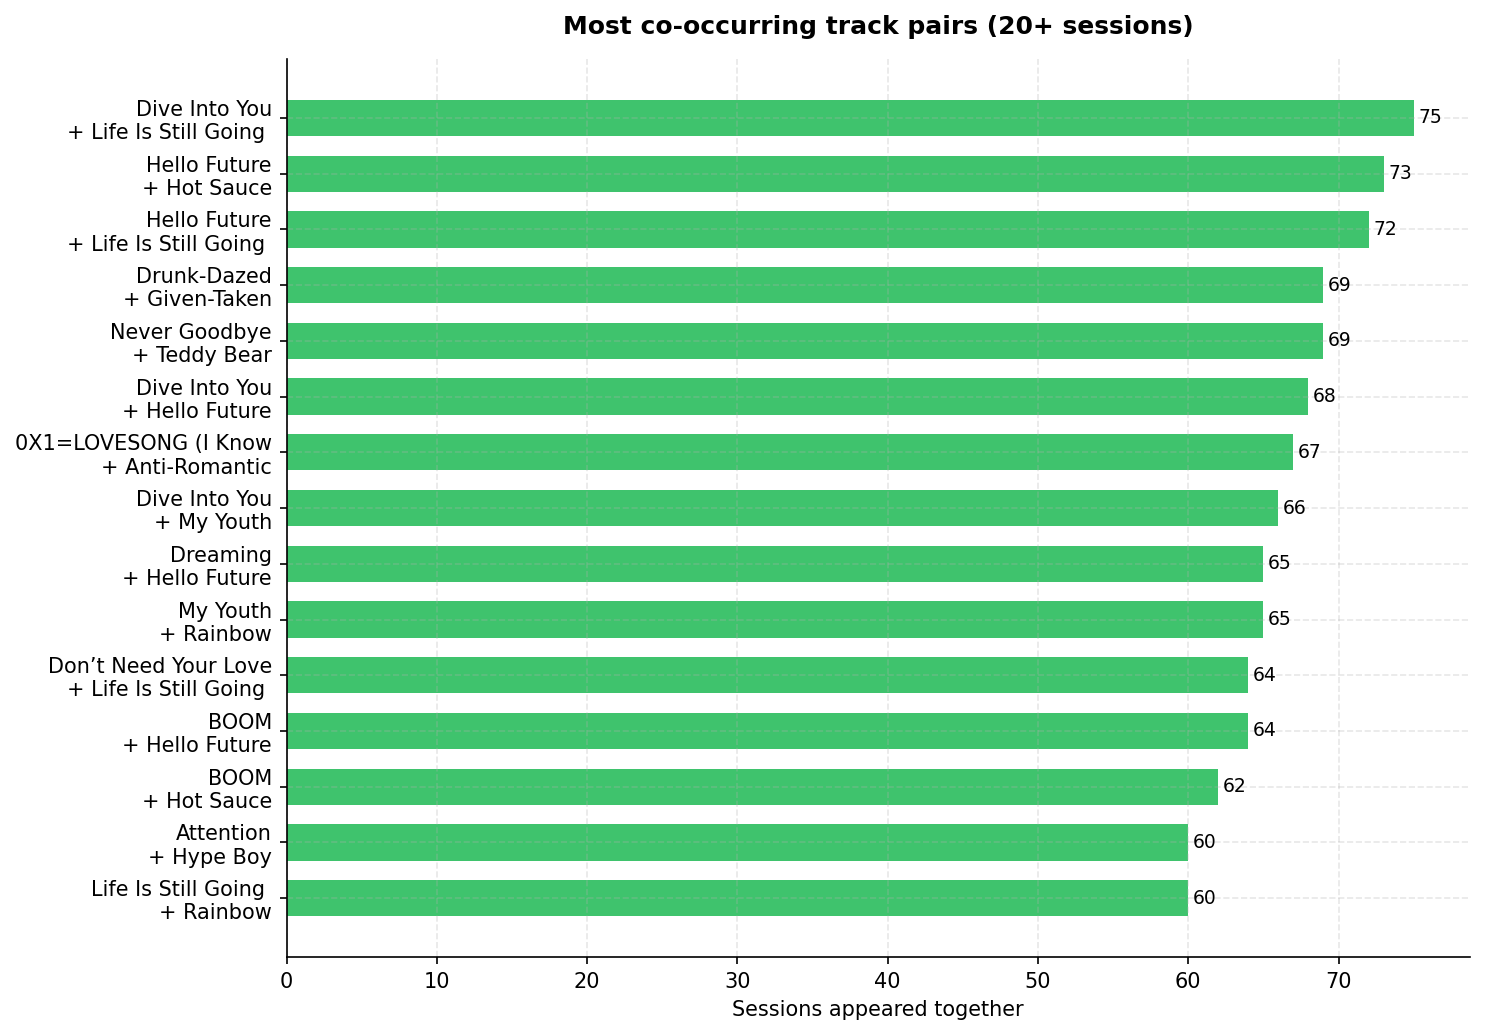

In [25]:
# Visualise top pairs
top15 = sim_df[sim_df["cooc_count"] >= 20].sort_values(
    "cooc_count", ascending=False).head(15)

labels = [f"{r['track_a'][:20]}\n+ {r['track_b'][:20]}"
          for _, r in top15.iterrows()]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(labels[::-1], top15["cooc_count"].values[::-1],
        color=PALETTE["primary"], alpha=0.85, edgecolor="none", height=0.65)
ax.set_title("Most co-occurring track pairs (20+ sessions)",
             fontweight="bold", pad=12)
ax.set_xlabel("Sessions appeared together")
for i, v in enumerate(top15["cooc_count"].values[::-1]):
    ax.text(v + 0.3, i, str(v), va="center", fontsize=9)

plt.tight_layout()
plt.savefig("../outputs/04_top_cooccurrence_pairs.png", bbox_inches="tight")
plt.show()


---
## 8. Sequential listening patterns

Sequential plays -- where track B was played immediately after track A -- are the strongest signal in the dataset. These are not coincidental co-occurrences but deliberate listening choices.


In [26]:
seq_df = pd.DataFrame([
    {
        "from_track":  k[0].split(" ||| ")[0],
        "from_artist": k[0].split(" ||| ")[1],
        "to_track":    k[1].split(" ||| ")[0],
        "to_artist":   k[1].split(" ||| ")[1],
        "count":       v,
    }
    for k, v in sequential.items()
]).sort_values("count", ascending=False)

print("Top 20 most common sequential plays:")
print(seq_df.head(20).to_string(index=False))


Top 20 most common sequential plays:
                 from_track           from_artist                                     to_track             to_artist  count
          Andhamaa Andhamaa    Hesham Abdul Wahab                                Parichayamila    Hesham Abdul Wahab    109
              Parichayamila    Hesham Abdul Wahab                            Andhamaa Andhamaa    Hesham Abdul Wahab    108
              Camera Lights               HAECHAN                                         CRZY               HAECHAN     54
                 Inthandham Vishal Chandrashekhar                            Kaanunna Kalyanam Vishal Chandrashekhar     50
          Kaanunna Kalyanam Vishal Chandrashekhar                                     Oh Prema Vishal Chandrashekhar     48
                   Hype Boy              NewJeans                                       Cookie              NewJeans     47
                       ISTJ             NCT DREAM                              Broken Melodies 

The top sequential pairs reveal album listening patterns -- tracks from the same album or artist played in a consistent order across many sessions. Andhamaa Andhamaa and Parichayamila being the top pair reflects a very specific listening habit.


## 9. Year by Year Top Tracks

In [28]:
df_tracks["year"] = df_tracks["ts_local"].dt.year
yearly_top = {}
for yr in sorted(df_tracks["year"].unique()):
    top3 = (df_tracks[df_tracks["year"] == yr]["track_name"]
            .value_counts().head(3))
    yearly_top[yr] = top3

for yr, top in yearly_top.items():
    print(f"\n{yr}")
    for track, count in top.items():
        print(f"  {track}  ({count})")


2020
  Go away go away  (38)
  Psycho  (29)
  Stay  (29)

2021
  Amusement Park  (133)
  My Love  (96)
  Anti-Romantic  (93)

2022
  Teddy Bear  (445)
  In My Dreams  (193)
  Hello Future  (173)

2023
  Teddy Bear  (409)
  Like We Just Met  (271)
  Moon  (174)

2024
  Like We Just Met  (138)
  Baby Don’t Like It 나쁜 짓  (121)
  Rains in Heaven  (96)

2025
  Seethakaalam (Reprise)  (646)
  Parichayamila  (228)
  Prema Velluva (From "Hit - 3") (Telugu)  (203)

2026
  NOT CUTE ANYMORE  (181)
  Kshanam  (80)
  for a bit  (78)


Teddy Bear held the top spot in both 2022 and 2023. By 2025 it had 
dropped out entirely, replaced by Telugu film music. The 2026 list 
reflects only the first few months of the year so it is not 
comparable to the full years.

## 10. Forgotten Favourites

In [29]:
track_stats = df_tracks.groupby(["track_name", "artist_name"]).agg(
    plays         = ("track_name",  "count"),
    completion    = ("completed",   "mean"),
    skip_rate     = ("skipped",     "mean"),
    unique_years  = ("year",        "nunique"),
).reset_index()

track_stats["plays_log"] = np.log1p(track_stats["plays"])
track_stats["engagement"] = (
    0.4 * track_stats["plays_log"]  / track_stats["plays_log"].max() +
    0.3 * track_stats["completion"] +
    0.2 * (1 - track_stats["skip_rate"]) +
    0.1 * track_stats["unique_years"] / track_stats["unique_years"].max()
)

last_played = (df_tracks.groupby("track_name")["ts"]
               .max().reset_index())
last_played.columns = ["track_name", "last_played"]

track_stats = track_stats.merge(last_played, on="track_name", how="left")

cutoff   = pd.Timestamp("2025-01-01", tz="UTC")
forgotten = track_stats[
    (track_stats["engagement"] > 0.6) &
    (track_stats["last_played"] < cutoff) &
    (track_stats["plays"] >= 20)
].sort_values("engagement", ascending=False)

print(f"High engagement tracks not played since Jan 2025: {len(forgotten)}")
print()
print(forgotten[["track_name","artist_name","plays",
                  "last_played","engagement"]].head(15).to_string(index=False))

High engagement tracks not played since Jan 2025: 31

                         track_name         artist_name  plays               last_played  engagement
                       Not For Sale             ENHYPEN     76 2024-11-19 20:46:29+00:00    0.749828
                Upper Side Dreamin’             ENHYPEN     90 2024-12-13 05:57:12+00:00    0.726849
Highway to Heaven - English Version             NCT 127    104 2024-09-17 19:03:19+00:00    0.714004
                            Flicker             ENHYPEN     50 2024-10-30 04:00:24+00:00    0.697575
          Bittersweet (feat. LeeHi)              WONWOO    128 2024-10-24 16:36:13+00:00    0.697045
                          New Rules TOMORROW X TOGETHER     48 2023-04-20 03:27:48+00:00    0.696256
                   Walk On Memories                 EXO     21 2022-07-21 09:35:33+00:00    0.690725
                  Can't You See Me? TOMORROW X TOGETHER     43 2023-07-11 13:11:56+00:00    0.684443
                           Mixed Up  

Most of the forgotten favourites are ENHYPEN and TOMORROW X TOGETHER 
tracks from 2023 and 2024. The drop-off coincides with the shift 
toward Telugu film music in 2025 -- not a sign of disengagement, 
just a change in what was being listened to.

## 11. Save artifacts

In [27]:
sim_df.to_csv("../data/processed/cooccurrence_similarity.csv", index=False)
seq_df.to_csv("../data/processed/sequential_patterns.csv",     index=False)

joblib.dump(sim_df, "../models/cooccurrence_recommender.pkl")

print("Saved: data/processed/cooccurrence_similarity.csv")
print("Saved: data/processed/sequential_patterns.csv")
print("Saved: models/cooccurrence_recommender.pkl")
print(f"\nSimilarity pairs: {len(sim_df):,}")
print(f"Sequential pairs: {len(seq_df):,}")


Saved: data/processed/cooccurrence_similarity.csv
Saved: data/processed/sequential_patterns.csv
Saved: models/cooccurrence_recommender.pkl

Similarity pairs: 50,682
Sequential pairs: 47,092


---
## Reflections

Three external data sources were attempted before arriving at this approach. Spotify's audio features API was deprecated in November 2024. A 1.2 million track Kaggle dataset matched 37% of the catalog, with K-pop and Telugu tracks largely absent. Last.fm tags matched 11% for the same reason.

The session co-occurrence approach turned that constraint into an advantage. The recommender is built entirely from personal listening behaviour -- no external database, no coverage gaps, no dependency on a third-party API. It reflects how this specific listener actually organizes music in their head, not how a general population does.

The Dice coefficient normalization ensures that high-play tracks do not dominate the recommendations simply by virtue of being played often. The sequential bonus rewards the strongest signal -- deliberate, back-to-back listening choices made repeatedly across many sessions.

The dashboard in the next step brings this recommender into an interactive interface where any track can be queried and results explored visually.
